# **Regression Model Exploration**

The following book explores various regression models to be used to predict the permanent magnet temperature in a PM motor.

## **Imports**

In [14]:
# Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SkLearn preprocessing imports
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GridSearchCV, train_test_split, RepeatedKFold
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer

# SkLearn model imports
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR, LinearSVR
from sklearn.base import BaseEstimator, RegressorMixin



In [15]:
# # Machine Learning library imports
# import tensorflow as tf
# from tensorflow import keras
# from keras.models import Sequential
# from tensorflow.keras import layers
# from keras.layers import Dense, BatchNormalization, Dropout
# from keras.optimizers import Adam, SGD, RMSprop, Adadelta, Adagrad, Adamax, Nadam, Ftrl
# from keras.callbacks import EarlyStopping, ModelCheckpoint
# from scikeras.wrappers import KerasClassifier, KerasRegressor
# from tensorflow.keras.layers import LeakyReLU
# from functools import partial
# from tensorflow.keras import models

# #Other library imports
# from bayes_opt import BayesianOptimization

In [16]:
pd.set_option('display.max_colwidth', None)  # Prevent column truncation
pd.set_option('display.expand_frame_repr', False)  # Prevent line wrapping
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)  # Show all rows

## **Data Manipulation and Preprocessing**

First we load the data, then drop unnecessary columns, and then reorder the columns to group by similarity.

In [17]:
df = pd.read_csv('measures_v2.csv')
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


In [18]:
cols_to_drop = [
    'profile_id',
    # 'torque',
    'stator_tooth',
    'stator_winding'
]
columns_order = [
    'u_q', 
    'u_d', 
    'i_q', 
    'i_d',
    'torque',
    'motor_speed', 
    'ambient', 
    'coolant', 
    'stator_yoke', 
    'pm'
]

df = df.drop(cols_to_drop, axis=1)
df = df[columns_order]
df = df.dropna()
df.head()

,u_q,u_d,i_q,i_d,torque,motor_speed,ambient,coolant,stator_yoke,pm
0,-0.450682,-0.350055,0.000328,0.004419,0.187101,0.002866,19.850691,18.805172,18.316547,24.554214
1,-0.325737,-0.305803,-0.000785,0.000606,0.245417,0.000257,19.850672,18.818571,18.314955,24.538078
2,-0.440864,-0.372503,0.000386,0.001290,0.176615,0.002355,19.850657,18.828770,18.326307,24.544693
3,-0.327026,-0.316199,0.002046,0.000026,0.238303,0.006105,19.850647,18.835567,18.330833,24.554018
4,-0.471150,-0.332272,0.037184,-0.064317,0.208197,0.003133,19.850639,18.857033,18.326662,24.565397


Now let's split our dataset into the feature set `X` and label set `y`.

In [19]:
X = df.drop('pm', axis=1)
y = df['pm']

Next we'll split the data into a training and test set.

In [20]:
TEST_SIZE = 0.3

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42)

In [21]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (931571, 9)
X_test shape: (399245, 9)


Now we'll make a pipeline that scales the data. 

In [22]:
data_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('pca', PCA(n_components=4))
])

## **Baseline Model Exploration**

Let's define a function to train multiple models and output their results as a dataframe by first performing grid search for hyperparameter optimization, then cross-validation to evaluate the training of the models.

In [30]:
def train_multi_models(models: dict, param_grids: dict, metrics: list, X_train: pd.DataFrame, y_train: pd.Series):
    results = []

    # Perform cross-validation for each model
    for name, model in models.items():
        print(f'Running cross-validation for model: {name}')
        
        # Create model pipeline
        model_pipeline = Pipeline([
            ('data_processing', data_pipeline),
            ('model', model)
        ])
        
        # Tune hyperparameters if a parameter grid is provided
        if name in param_grids:
            grid_search = GridSearchCV(
                model_pipeline,
                param_grid = param_grids[name],
                scoring = metrics,
                refit = 'neg_mean_absolute_error',
                cv = 5
            )
            grid_search.fit(X_train, y_train)
            best_pipeline = grid_search.best_estimator_
            best_params = grid_search.best_params_
        else:
            best_pipeline = model_pipeline
            best_pipeline.fit(X_train, y_train)
            best_params = None
        
        # Perform cross-validation
        scores = cross_validate(
            best_pipeline,
            X_train,
            y_train,
            scoring=metrics,
            cv = 5,
            return_train_score=True
        )

        # Store results
        results.append({
            'Model': name,
            'Train MAE': -np.mean(scores['train_neg_mean_absolute_error']),
            'Validation MAE': -np.mean(scores['test_neg_mean_absolute_error']),
            'Train MSE': -np.mean(scores['train_neg_mean_squared_error']),
            'Validation MSE': -np.mean(scores['test_neg_mean_squared_error']),
            'Train R²': np.mean(scores['train_r2']),
            'Validation R²': np.mean(scores['test_r2'])
        })
    
    print('Training complete!')

    # Convert results into a DataFrame
    results_df = pd.DataFrame(results)
    return(results_df)

In [31]:
models = {
    'Dummy Regressor' : DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    # 'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
    'SVR': LinearSVR()
}

param_grids = {
    'Ridge': {'model__alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'model__alpha': [0.01, 0.1, 1.0, 10.0]},
    'ElasticNet': {
        'model__alpha': [0.01, 0.1, 1.0],
        'model__l1_ratio': [0.2, 0.5, 0.8]
    }
}

scoring_metrics = [
    'neg_mean_absolute_error',
    'neg_mean_squared_error',
    'r2'
]

In [32]:
baseline_model_results = train_multi_models(models, param_grids, scoring_metrics, X_train, y_train)
baseline_model_results

Running cross-validation for model: Dummy Regressor
Running cross-validation for model: Linear Regression
Running cross-validation for model: Ridge
Running cross-validation for model: Lasso
Running cross-validation for model: ElasticNet
Running cross-validation for model: SVR
Training complete!


,Model,Train MAE,Validation MAE,Train MSE,Validation MSE,Train R²,Validation R²
0,Dummy Regressor,15.917501,15.917515,360.890534,360.891247,0.000000,-0.000005
1,Linear Regression,5.996245,5.996330,63.354364,63.356350,0.824450,0.824444
2,Ridge,5.996245,5.996331,63.354364,63.356350,0.824450,0.824444
3,Lasso,6.000525,6.000592,63.396608,63.398124,0.824333,0.824329
4,ElasticNet,6.014229,6.014299,63.485474,63.486989,0.824087,0.824082
5,SVR,5.863953,5.864021,65.865361,65.866754,0.817492,0.817488


Looking above, Ridge provided the best results validation R2 but just slightly over ridge and lasso. ElascticNet had similar results but DummyRegressor provided the worst results. SVR, although produced the worst results in terms of R2, provided the lowest MAE values, providing an indication that the margin of error within the predicted points was the lowest and in turn, the closest. Sadly though, the more complex SVR models carry a significantly higher computational cost and in turn, makes it unfeasible to include as part of the ML models.  

## **Feature Reduction using Recursive Feature Elimination**

Running machine learning models is computationally expensive and becomes more demanding the larger the dataset. With over 1 Million datapoints and 9 features, it is important to reduce the number of features used in the dataset. Furthermore, it is useful to understand the importance of each feature when predicting outputs within both a linear and non-linear model. This is why a wrapper method was applied to determine the best combination of features which would provide an optimal accuracy with the use of a strategy called Recursive Feature Elimination (RFE). RFE is a technique used to provide specific number of features required for adequate performance through importance. It does so by including all the features within the dataset and ranking them based on either their importance or contribution to accuracy. It removes the insignificant features and outputs the optimal number of features required. Exhaustive search explores every combination possibility within the features and determines the best set for accuracy. An issue with this is that it is computationally expensive due to the plethora of features contributed by the chosen dataset but only requires us to do so once before hypertuning ML models. The models chosen for feature selection importance were Linear Regression and Random Forest Regression.  

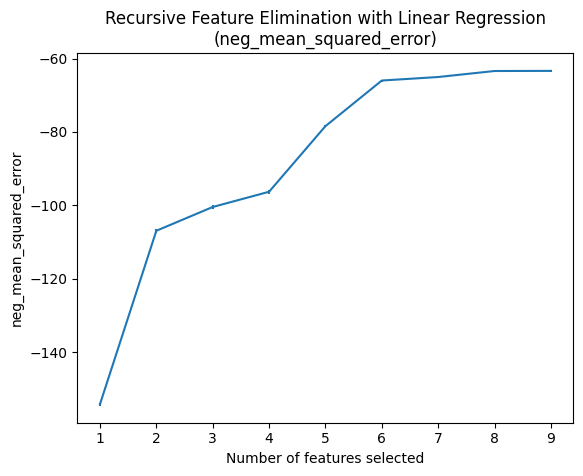

Optimal number of features: 9
Selected features: Index(['u_q', 'u_d', 'i_q', 'i_d', 'torque', 'motor_speed', 'ambient',
       'coolant', 'stator_yoke'],
      dtype='object')
Feature rankings: [1 1 1 1 1 1 1 1 1]

Feature Selection Process:

With 1 features, Score = -154.1799
Selected Features: [np.str_('u_q')]
--------------------------------------------------
With 2 features, Score = -106.9209
Selected Features: [np.str_('u_q'), np.str_('u_d')]
--------------------------------------------------
With 3 features, Score = -100.4448
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q')]
--------------------------------------------------
With 4 features, Score = -96.2908
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q'), np.str_('i_d')]
--------------------------------------------------
With 5 features, Score = -78.4227
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q'), np.str_('i_d'), np.str_('torque')]
-------------------------------------

In [44]:
model = LinearRegression()

# Define scoring metrics
scoring_metrics = ['neg_mean_absolute_error', 'r2']

# Initialize results list
results = []

# Define RFECV parameters
min_features_to_select = 1
cv = 5

# Create model pipeline with RFECV
model_pipeline = Pipeline([
    ('data_processing', data_pipeline),  # Use the data pipeline
    ('feature_selection', RFECV(
        estimator=model,  # Use LinearRegression as the base estimator for RFECV
        step=1,
        cv=cv,
        scoring="neg_mean_squared_error",
        min_features_to_select=min_features_to_select,
        n_jobs=2
    )),
    ('model', model)  # Add the Linear Regression model
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Extract RFECV results
rfecv = model_pipeline.named_steps['feature_selection']

# Make predictions
y_pred = model_pipeline.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Store results
results.append({
    'Model': model,
    'MSE': mse,
    'MAE': mae,
    'RMSE': rmse,
    'R²': r2,
    'Optimal Features': rfecv.n_features_
})

# Plot RFECV results
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("neg_mean_squared_error")
plt.errorbar(
    range(min_features_to_select, len(rfecv.cv_results_["mean_test_score"]) + min_features_to_select),
    rfecv.cv_results_["mean_test_score"],
    yerr=rfecv.cv_results_["std_test_score"],
)
plt.title("Recursive Feature Elimination with Linear Regression\n(neg_mean_squared_error)")
plt.show()

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {X.columns[rfecv.support_]}")
print(f"Feature rankings: {rfecv.ranking_}")
print()

mean_scores = rfecv.cv_results_["mean_test_score"]
features = list(X.columns)
ranking = np.array(rfecv.ranking_)

sorted_indices = np.argsort(ranking)
sorted_features = np.array(features)[sorted_indices]

selected_features = list(sorted_features)

print("Feature Selection Process:\n")
for num_features in range(1, len(features) + 1):
    score = mean_scores[num_features - 1]

    print(f"With {num_features} features, Score = {score:.4f}")
    print(f"Selected Features: {selected_features[:num_features]}")
    print("-" * 50)

# Convert results into a DataFrame
results_df_RFECV_LR = pd.DataFrame(results)
print(results_df_RFECV_LR)


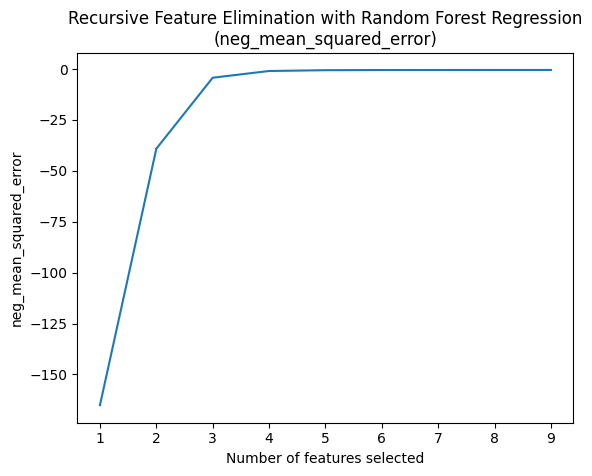

Optimal number of features: 9
Selected features: Index(['u_q', 'u_d', 'i_q', 'i_d', 'torque', 'motor_speed', 'ambient',
       'coolant', 'stator_yoke'],
      dtype='object')
Feature rankings: [1 1 1 1 1 1 1 1 1]

Feature Selection Process:

With 1 features, Score = -165.0536
Selected Features: [np.str_('u_q')]
--------------------------------------------------
With 2 features, Score = -39.1180
Selected Features: [np.str_('u_q'), np.str_('u_d')]
--------------------------------------------------
With 3 features, Score = -4.2395
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q')]
--------------------------------------------------
With 4 features, Score = -0.9462
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q'), np.str_('i_d')]
--------------------------------------------------
With 5 features, Score = -0.5510
Selected Features: [np.str_('u_q'), np.str_('u_d'), np.str_('i_q'), np.str_('i_d'), np.str_('torque')]
------------------------------------------

In [31]:
model = RandomForestRegressor()

# Define scoring metrics
scoring_metrics = ['neg_mean_absolute_error', 'r2']

# Initialize results list
results = []

# Define RFECV parameters
min_features_to_select = 1
cv = 5

# Create model pipeline with RFECV
model_pipeline = Pipeline([
    ('data_processing', data_pipeline),  # Use the data pipeline
    ('feature_selection', RFECV(
        estimator=model,  # Use RandomForestRegressor as the base estimator for RFECV
        step=1,
        cv=cv,
        scoring="neg_mean_squared_error",
        min_features_to_select=min_features_to_select,
        n_jobs=2
    ))
    ('model', model)  # Add the Random Forest Regression model
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Extract RFECV results
rfecv = model_pipeline.named_steps['feature_selection']

# Make predictions
y_pred = model_pipeline.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Store results
results.append({
    'Model': model,
    'MSE': mse,
    'MAE': mae,
    'RMSE': rmse,
    'R²': r2,
    'Optimal Features': rfecv.n_features_
})

# Plot RFECV results
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("neg_mean_squared_error")
plt.errorbar(
    range(min_features_to_select, len(rfecv.cv_results_["mean_test_score"]) + min_features_to_select),
    rfecv.cv_results_["mean_test_score"],
    yerr=rfecv.cv_results_["std_test_score"],
)
plt.title("Recursive Feature Elimination with Random Forest Regression\n(neg_mean_squared_error)")
plt.show()

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {X.columns[rfecv.support_]}")
print(f"Feature rankings: {rfecv.ranking_}")
print()

mean_scores = rfecv.cv_results_["mean_test_score"]
features = list(X.columns)
ranking = np.array(rfecv.ranking_)

sorted_indices = np.argsort(ranking)
sorted_features = np.array(features)[sorted_indices]

selected_features = list(sorted_features)

print("Feature Selection Process:\n")
for num_features in range(1, len(features) + 1):
    score = mean_scores[num_features - 1]

    print(f"With {num_features} features, Score = {score:.4f}")
    print(f"Selected Features: {selected_features[:num_features]}")
    print("-" * 50)

# Convert results into a DataFrame
results_df_RFECV_RFR = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None)  # Prevent column truncation
pd.set_option('display.expand_frame_repr', False)  # Prevent line wrapping
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)  # Show all rows
print(results_df_RFECV_RFR)

## **Return to Baseline Model Exploration: Eliminating Features**

From the output of the recursive feature elimination, we can try to see how well the models perform using fewer features by selecting the number of feature where a 'knee' is present in the plots above. The goal of this is to be able to train a high-fidelity model while reducing the computational cost for training and storage. From the outputs above, specifically for linear regression, we see a knee at 6 features after which the results do not really improve. Let's look at the baseline models again while removing the features past 6 features.

In [37]:
reduced_x_train = X_train.drop(columns=['ambient', 'coolant', 'stator_yoke'])
baseline_model_results_fr = train_multi_models(models, param_grids, scoring_metrics, reduced_x_train, y_train)
baseline_model_results_fr

Running cross-validation for model: Dummy Regressor
Running cross-validation for model: Linear Regression
Running cross-validation for model: Ridge
Running cross-validation for model: Lasso
Running cross-validation for model: ElasticNet
Running cross-validation for model: SVR
Training complete!


,Model,Train MAE,Validation MAE,Train MSE,Validation MSE,Train R²,Validation R²
0,Dummy Regressor,15.917501,15.917515,360.890534,360.891247,0.000000,-0.000005
1,Linear Regression,12.998121,12.998265,247.361888,247.368076,0.314579,0.314560
2,Ridge,12.997922,12.998065,247.362525,247.368698,0.314577,0.314558
3,Lasso,12.998631,12.998769,247.387738,247.393725,0.314508,0.314488
4,ElasticNet,13.001533,13.001672,247.410490,247.416552,0.314444,0.314425
5,SVR,12.855880,12.855846,253.087151,253.081749,0.298715,0.298727


## **Additional Algorithm Exploration**

Artificial neural networks (ANN) attempt to replicate a learning algorithm that simulates how neurons in human brains process information and are classified as supervised or unsupervised learning models. It can be classified under two general sets of techniques, a feedforward neural network (FNN) and a recurrent neural network (RNN) with a plethora of concepts derived from them. The differing point with RNN is that there is a delayed updating term within each node in the hidden layer. It is “self-taught” and updated using information provided from the layer and/or time increment before and is iterative over a larger model with more layers. For this report, a deep feed forward neural network (DFNN) is applied to the data. The DFNN architecture consists of an input layer, one or more hidden layers, and an output layer. This neural network begins by passing information from an input layer, through hidden layers containing “neurons” (nodes) deriving relationships between one another, and the output layer. It is considered deep because it contains more than 1 hidden layer, allowing it to capture high-level nuances in the data. It is named a FFN because it only provides the input in only one way and does not pass information from the output back through the neurons. An activation function is provided to both the hidden layers and the output to provide better correlation between the varying features. The batch size and epochs used within the model when selected allows for the number of test selections and training iterations that the model will undergo during the modelling process. 

Random Forest is a supervised machine-learning algorithm used for classification or regression tasks. It operates by constructing an ensemble of decision trees, where each tree is trained on a random subset of the training data and features. This random sampling with replacement ensures that each tree in the forest learns from a diverse subset of the data, reducing the risk of overfitting and improving generalization. At the core of Random Forest is the concept of bagging, where multiple decision trees are trained independently on different subsets of the data. During training, each tree is grown using a subset of the features selected randomly at each split, further enhancing diversity and reducing correlation between trees. Each tree in the forest independently predicts the outcome, and the final prediction is determined by aggregating the individual predictions of all trees. The goal is to harness the diversity of multiple trees to enhance predictive accuracy and mitigate overfitting. This technique is particularly effective in handling large datasets, high dimensionality, and intricate relationships within the data. However, its interpretability may be challenging due to its complexity.

In [28]:
scoring = {
    'mse': make_scorer(mean_squared_error, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': make_scorer(r2_score, greater_is_better=True)
}

def RF_model(X_train, y_train, X_test, y_test):
    # Create a Random Forest Regressor model
    rf_model = RandomForestRegressor()
    # Create a pipeline with preprocessing and model
    model_pipeline = Pipeline([
        ('data_processing', data_pipeline),
        ('model', rf_model)
    ])

    # Perform cross-validation
    cv = 5
    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        return_train_score=True,
        n_jobs=2
    )

    # Train final model on full training data
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    # Evaluate on test set
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results in a dictionary
    results_RF = {
        'Train MSE': -np.mean(scores['train_mse']),
        'Validation MSE': -np.mean(scores['test_mse']),
        'Train MAE': -np.mean(scores['train_mae']),
        'Validation MAE': -np.mean(scores['test_mae']),
        'Train R²': np.mean(scores['train_r2']),
        'Validation R²': np.mean(scores['test_r2']),
        'Test MSE': mse,
        'Test MAE': mae,
        'Test RMSE': rmse,
        'Test R²': r2
    }

    # Display performance summary
    results_df_RF = pd.DataFrame([results_RF])
    print("\nEvaluation Metrics:")
    print(results_df_RF)

    return mse, mae, rmse, r2, results_df_RF

In [23]:
def create_ann():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Custom wrapper to fix KerasRegressor warning and compatibility issues
class KerasWrapper(KerasRegressor, BaseEstimator, RegressorMixin):
    def __sklearn_tags__(self):
        return {'requires_y': True}

# Create a pipeline with scaling and ANN model
def ANN_model(X_train, y_train, X_test, y_test, cv=5):
    # Create the pipeline
    model_pipeline = Pipeline([
        ('data_processing', data_pipeline),
        ('model', model)
    ])

    # Perform cross-validation
    cv_results = cross_validate(model_pipeline, X_train, y_train, cv=cv, scoring='neg_mean_squared_error', return_train_score=True)

    # Compute mean scores directly from the dictionary
    train_mse = -np.mean(cv_results['train_score'])
    val_mse = -np.mean(cv_results['test_score'])

    # Fit the model to get predictions
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results in a dictionary
    results_ANN = {
        'Train MSE': -np.mean(scores['train_mse']),
        'Validation MSE': -np.mean(scores['test_mse']),
        'Train MAE': -np.mean(scores['train_mae']),
        'Validation MAE': -np.mean(scores['test_mae']),
        'Train R²': np.mean(scores['train_r2']),
        'Validation R²': np.mean(scores['test_r2']),
        'Test MSE': mse,
        'Test MAE': mae,
        'Test RMSE': rmse,
        'Test R²': r2
    }

    # Display performance summary
    results_df_ANN = pd.DataFrame([results_ANN])
    print("\nEvaluation Metrics:")
    print(results_df_ANN)

    return mse, mae, rmse, r2, results_df_ANN, cv_results

In [24]:
# Train and evaluate ANN model
ann_mse, ann_mae, ann_rmse, ann_r2, results_df_ANN, cv_results = ANN_model(X_train, y_train, X_test, y_test)
print("ANN Metrics:")
print(f'MSE: {ann_mse:.2f}')
print(f'MAE: {ann_mae:.2f}')
print(f'RMSE: {ann_rmse:.2f}')
print(f'R^2: {ann_r2:.2f}')
print(results_df_ANN)
print(cv_results)


Evaluation Metrics:
   Train MSE  Validation MSE  Train MAE  Validation MAE  Train R²  Validation R²  Test MSE  Test MAE  Test RMSE   Test R²
0   0.064238        0.444761   0.078582        0.208461  0.999822       0.998768  0.342747  0.182469   0.585446  0.999052
ANN Metrics:
MSE: 0.34
MAE: 0.18
RMSE: 0.59
R^2: 1.00
   Train MSE  Validation MSE  Train MAE  Validation MAE  Train R²  Validation R²  Test MSE  Test MAE  Test RMSE   Test R²
0   0.064238        0.444761   0.078582        0.208461  0.999822       0.998768  0.342747  0.182469   0.585446  0.999052
{'fit_time': array([1085.19559884, 1088.11954927, 1075.57480931, 1077.1696434 ,
       1078.15103221]), 'score_time': array([7.31895733, 7.29801416, 7.27456427, 7.1773324 , 7.17622542]), 'test_score': array([-0.43814865, -0.3923086 , -0.48328264, -0.46736588, -0.42984027]), 'train_score': array([-0.06397268, -0.06456052, -0.06420483, -0.06278402, -0.064365  ])}


In [29]:
# Train and evaluate Random Forest model
rf_mse, rf_mae, rf_rmse, rf_r2, results_df_RF = RF_model(X_train, y_train, X_test, y_test)
print("Random Forest Metrics:")
print(f'MSE: {rf_mse:.2f}')
print(f'MAE: {rf_mae:.2f}')
print(f'RMSE: {rf_rmse:.2f}')
print(f'R^2: {rf_r2:.2f}')


Evaluation Metrics:
   Train MSE  Validation MSE  Train MAE  Validation MAE  Train R²  Validation R²  Test MSE  Test MAE  Test RMSE   Test R²
0   0.063725        0.445328   0.078604        0.208398  0.999823       0.998766  0.345691  0.182485   0.587955  0.999044
Random Forest Metrics:
MSE: 0.35
MAE: 0.18
RMSE: 0.59
R^2: 1.00


In [32]:
print(results_df_RF)

   Train MSE  Validation MSE  Train MAE  Validation MAE  Train R²  Validation R²  Test MSE  Test MAE  Test RMSE   Test R²
0   0.063725        0.445328   0.078604        0.208398  0.999823       0.998766  0.345691  0.182485   0.587955  0.999044


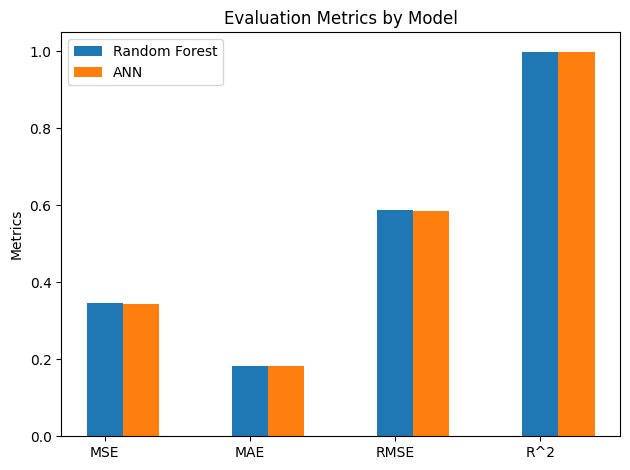

In [33]:
# Plot the evaluation metrics
labels = ['MSE', 'MAE', 'RMSE', 'R^2']
rf_metrics = [rf_mse, rf_mae, rf_rmse, rf_r2]
ann_metrics = [ann_mse, ann_mae, ann_rmse, ann_r2]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots()
rects1 = ax.bar(x, rf_metrics, width, label='Random Forest')
rects2 = ax.bar(x + width, ann_metrics, width, label='ANN')

ax.set_ylabel('Metrics')
ax.set_title('Evaluation Metrics by Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()

plt.show()

print()

Comparing these 2 models with simple, explicitly defined (or base) parameters provided a very high accuracy but at the cost of being computationally expensive. The goal for this project would be to reduce the number of features that the model accepts but at the same time, using hypertuning to achieve models that still have comparable accuracy. 

In [ ]:
#Would you wanna go on this path for the project, achieve the same accuracy but using a significant amount less in the hypertuning models? 

Hypertuning is a method in which iterations test varying potential parameter values are evaluated in contrast with a specified cross validation score. Two varying approaches were taken to optimize the model and determine the optimal parameters, grid search and Bayesian Optimization.  Grid search optimization determines the optimal parameters by conducting an exhaustive search for the provided parameter conditions. This method evaluates each combination of hyperparameters and selects the one that maximizes the specified evaluation metric. This becomes computationally expensive as the size of the dataset and the numbers of parameter options increase. However, it ensures a thorough exploration of the hyperparameter space which provides the reasoning behind the high computational cost. In contrast, Bayesian optimization compares to gradient descent in that it takes all the parameters and goes in the direction of improving accuracy. Once all directions have been exhausted, the set of parameters with the most accurate predictions is chosen. The reasoning why these two optimization methods were used is due to their approaches when it came to tuning. Although both methods are capable of hyper tuning parameters, they do so with differing mathematical approaches. Through this, a rough analysis could be done to determine further optimization techniques with similar methodologies to the best technique. A comparison between the simple, grid search, and Bayesian tuned parameters was done to determine if accuracy could be retrieved. 

In [55]:
def RF_model_BO(X_train, y_train, X_test, y_test):
    # Define the pipeline
    pipeline = Pipeline([
        ('data_processing', data_pipeline),  # Standardize features
        ('model', RandomForestRegressor())  # Random Forest model
    ])

    # Define the objective function for Bayesian Optimization
    def RF_model_objective(n_estimators, min_samples_split, min_samples_leaf):
        # Update the pipeline with the current hyperparameters
        pipeline.set_params(
            model__n_estimators=int(n_estimators),
            model__min_samples_split=int(min_samples_split),
            model__min_samples_leaf=int(min_samples_leaf)
        )

        # Perform cross-validation
        cv = 5
        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring="neg_mean_squared_error",  # Use negative MSE for scoring
            n_jobs=-1
        )

        # Return the mean of the test scores (negative MSE)
        return np.mean(scores['test_score'])

    # Define the parameter grid for Bayesian Optimization
    param_grid = {
        'n_estimators': (75, 150),
        'min_samples_split': (2, 5),
        'min_samples_leaf': (1, 4),
    }

    # Perform Bayesian Optimization
    Bayesian_search = BayesianOptimization(f=RF_model_objective, pbounds=param_grid)
    Bayesian_search.maximize(init_points=3, n_iter=3)

    # Extract the best hyperparameters
    params = Bayesian_search.max['params']
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    print("Best Hyperparameters:", params)

    # Train the final model with the best hyperparameters
    pipeline.set_params(
        model__n_estimators=params['n_estimators'],
        model__min_samples_split=params['min_samples_split'],
        model__min_samples_leaf=params['min_samples_leaf']
    )
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Evaluate the tuned model
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("Evaluation Metrics:")
    print(f'MSE: {mse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R^2: {r2:.4f}')

    # Perform cross-validation on the final model
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring={
            'mse': make_scorer(mean_squared_error, greater_is_better=False),
            'mae': make_scorer(mean_absolute_error, greater_is_better=False),
            'r2': make_scorer(r2_score)
        },
        return_train_score=True,
        n_jobs=-1
    )

    # Calculate mean scores
    train_mse = -np.mean(cv_scores['train_mse'])
    val_mse = -np.mean(cv_scores['test_mse'])
    train_mae = -np.mean(cv_scores['train_mae'])
    val_mae = -np.mean(cv_scores['test_mae'])
    train_r2 = np.mean(cv_scores['train_r2'])
    val_r2 = np.mean(cv_scores['test_r2'])

    print("\nCross-Validation Scores:")
    print(f'Train MSE: {train_mse:.4f}')
    print(f'Validation MSE: {val_mse:.4f}')
    print(f'Train MAE: {train_mae:.4f}')
    print(f'Validation MAE: {val_mae:.4f}')
    print(f'Train R^2: {train_r2:.4f}')
    print(f'Validation R^2: {val_r2:.4f}')

    return mse, mae, rmse, r2, cv_scores

In [56]:
# Run the function
rf_mse, rf_mae, rf_rmse, rf_r2, cv_scores = RF_model_BO(X_train, y_train, X_test, y_test)
print("Random Forest Metrics:")
print(f'MSE: {rf_mse:.4f}')
print(f'MAE: {rf_mae:.4f}')
print(f'RMSE: {rf_rmse:.4f}')
print(f'R^2: {rf_r2:.4f}')
print(cv_scores)

|   iter    |  target   | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
def RF_modelGS(X_train, y_train, X_test, y_test):
    # Define the pipeline
    pipeline = Pipeline([
        ('data_processing', data_pipeline),  # Standardize features
        ('model', RandomForestRegressor())  # Random Forest model
    ])

    # Define the parameter grid for GridSearchCV
    param_grid = {
        'model__n_estimators': [50, 100, 200, 300],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4, 10]
    }

    # Define cross-validation strategy
    cv = 5

    # Perform GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    # Extract the best hyperparameters
    best_params = grid_search.best_params_
    print("Best Hyperparameters:", best_params)

    # Use the best model for predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Evaluate the tuned model on the test set
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("Test Set Evaluation Metrics:")
    print(f'MSE: {mse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R^2: {r2:.4f}')

    # Perform cross-validation on the best model to get cross-validation scores
    cv_scores = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'mse': make_scorer(mean_squared_error, greater_is_better=False),
            'mae': make_scorer(mean_absolute_error, greater_is_better=False),
            'r2': make_scorer(r2_score)
        },
        return_train_score=True,
        n_jobs=-1
    )

    # Extract and print cross-validation scores
    train_mse = -np.mean(cv_scores['train_mse'])
    val_mse = -np.mean(cv_scores['test_mse'])
    train_mae = -np.mean(cv_scores['train_mae'])
    val_mae = -np.mean(cv_scores['test_mae'])
    train_r2 = np.mean(cv_scores['train_r2'])
    val_r2 = np.mean(cv_scores['test_r2'])

    print("\nCross-Validation Scores:")
    print(f'Train MSE: {train_mse:.4f}')
    print(f'Validation MSE: {val_mse:.4f}')
    print(f'Train MAE: {train_mae:.4f}')
    print(f'Validation MAE: {val_mae:.4f}')
    print(f'Train R^2: {train_r2:.4f}')
    print(f'Validation R^2: {val_r2:.4f}')

    return mse, mae, rmse, r2

In [58]:
# Example usage
rf_mse, rf_mae, rf_rmse, rf_r2 = RF_modelGS(X_train, y_train, X_test, y_test)
print("Random Forest Metrics:")
print(f'MSE: {rf_mse:.4f}')
print(f'MAE: {rf_mae:.4f}')
print(f'RMSE: {rf_rmse:.4f}')
print(f'R^2: {rf_r2:.4f}')

KeyboardInterrupt: 

Explanation which produced better result for RF, Bayesian or Gridsearch optimization

In [100]:
class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, build_fn, epochs=100, batch_size=32, verbose=0):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None

    def fit(self, X, y):
        self.model = self.build_fn()
        es = EarlyStopping(monitor='loss', mode='min', verbose=0, patience=20)
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose, callbacks=[es])
        return self

    def predict(self, X):
        return self.model.predict(X).flatten()


# Fixed activation list using `partial`
activationL = ['relu', 'sigmoid', 'selu', 'exponential', partial(layers.LeakyReLU, alpha=0.1)]

# Neural Network for Bayesian Optimization
def nn_cl_bo(neurons, activation, learning_rate, batch_size, epochs, X_train, y_train):
    neurons = int(neurons)
    activation = activationL[round(activation)]  # Get the activation function
    batch_size = int(batch_size)
    epochs = int(epochs)

    # Define the model
    def nn_cl_fun():
        opt = Adam(learning_rate=learning_rate)
        model = Sequential([
            layers.Dense(neurons, input_dim=X_train.shape[1], activation=activation),
            layers.Dense(neurons, activation=activation),
            layers.Dense(1)
        ])
        model.compile(loss='mean_squared_error', optimizer=opt, metrics=['mean_squared_error'])
        return model

    # Wrap the model in KerasWrapper
    model = KerasWrapper(build_fn=nn_cl_fun, epochs=epochs, batch_size=batch_size, verbose=0)

    # Cross-validation without `fit_params`
    scores = cross_validate(
        model,
        X_train,
        y_train,
        scoring='neg_mean_squared_error',
        cv=5
    )

    # Calculate mean score
    score = np.mean(scores['test_score'])

    return score


# ANN model function using Bayesian Optimization
def ANN_modelBO(X_train, y_train, X_test, y_test):
    # Preprocessing pipeline (scaling)
    model_pipeline = Pipeline([
        ('data_processing', data_pipeline)
    ])

    # Fit pipeline on training data
    X_train = model_pipeline.fit_transform(X_train)
    X_test = model_pipeline.transform(X_test)

    # Search space for Bayesian Optimization
    params_ann_model = {
        'neurons': (5, 300),
        'activation': (0, 4),  # Index for activation functions
        'learning_rate': (0.0001, 0.1),
        'batch_size': (10, 2000),
        'epochs': (10, 500)
    }

    # Bayesian Optimization
    ann_bo = BayesianOptimization(
        f=lambda neurons, activation, learning_rate, batch_size, epochs: nn_cl_bo(
            neurons, activation, learning_rate, batch_size, epochs, X_train, y_train
        ),
        pbounds=params_ann_model,
    )

    # Run optimization
    ann_bo.maximize(init_points=3, n_iter=3)

    # Extract best parameters
    params_nn_ = ann_bo.max['params']
    params_nn_['activation'] = activationL[round(params_nn_['activation'])]  # Set correct activation function
    params_nn_['batch_size'] = int(params_nn_['batch_size'])
    params_nn_['neurons'] = int(params_nn_['neurons'])
    params_nn_['epochs'] = int(params_nn_['epochs'])

    print("\n✅ Best Hyperparameters:", params_nn_)

    # Final model based on best parameters
    def ann_cl_fun_final():
        model = Sequential([
            layers.Dense(params_nn_['neurons'], input_dim=X_train.shape[1], activation=params_nn_['activation']),
            layers.Dense(params_nn_['neurons'], activation=params_nn_['activation']),
            layers.Dense(1)
        ])
        model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=params_nn_['learning_rate']), metrics=['mean_squared_error'])
        return model

    # Train final model
    final_model = KerasWrapper(
        build_fn=ann_cl_fun_final,
        epochs=params_nn_['epochs'],
        batch_size=params_nn_['batch_size'],
        verbose=0
    )

    final_model.fit(X_train, y_train)

    # Make predictions
    y_pred = final_model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n🔎 Evaluation Metrics:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

    return mse, mae, rmse, r2

In [101]:
ann_mse, ann_mae, ann_rmse, ann_r2 = ANN_modelBO(X_train, y_train, X_test, y_test)

print("\nANN Metrics:")
print(f"MSE: {ann_mse:.4f}")
print(f"MAE: {ann_mae:.4f}")
print(f"RMSE: {ann_rmse:.4f}")
print(f"R²: {ann_r2:.4f}")

|   iter    |  target   | activa... | batch_... |  epochs   | learni... |  neurons  |
-------------------------------------------------------------------------------------


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5823/5823 ━━━━━━━━━━━━━━━━━━━━ 3s 476us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [106]:
# Custom wrapper to fix KerasRegressor warnings and compatibility issues
class KerasWrapper(KerasRegressor, BaseEstimator, RegressorMixin):
    def __sklearn_tags__(self):
        return {'requires_y': True}

# Model architecture function
def build_Ann():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(units=89, activation='relu'),
        tf.keras.layers.Dense(units=43, activation='relu'),
        tf.keras.layers.Dense(units=1)  # Single output for regression
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])
    return model

# ANN model function with data_pipeline integration
def ANN_modelGS(X_train, y_train, X_test, y_test):
    
    # Define model pipeline with data preprocessing + ANN model
    model_pipeline = Pipeline([
        ('preprocessor', data_pipeline),
        ('model', KerasWrapper(build_fn=build_Ann))
    ])

    # Define hyperparameter grid for tuning
    params_ann_model = {
        'model__batch_size': [50, 125, 200],
        'model__epochs': [1, 500]
    }

    # Cross-validation strategy
    cv = 5

    # Perform Grid Search with Cross Validation
    grid = GridSearchCV(
        estimator=model_pipeline,
        param_grid=params_ann_model,
        cv=cv,
        scoring='neg_mean_squared_error',
    )

    # Fit the grid search model
    grid_result = grid.fit(X_train, y_train)

    # Get the best hyperparameters
    best_params = grid_result.best_params_
    print("\n✅ Best Hyperparameters:", best_params)

    # Use the best model for prediction
    best_model = grid_result.best_estimator_
    y_pred = best_model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n🔎 Evaluation Metrics:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

    return mse, mae, rmse, r2

In [107]:
# Train and evaluate ANN model
ann_mse, ann_mae, ann_rmse, ann_r2 = ANN_modelGS(X_train, y_train, X_test, y_test)
print("ANN Metrics:")
print(f'MSE: {ann_mse:.4f}')
print(f'MAE: {ann_mae:.4f}')
print(f'RMSE: {ann_rmse:.4f}')
print(f'R^2: {ann_r2:.4f}')

c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KerasWrapper or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


14906/14906 ━━━━━━━━━━━━━━━━━━━━ 13s 840us/step - loss: 177.8298 - mean_squared_error: 177.8298
 230/3727 ━━━━━━━━━━━━━━━━━━━━ 1s 457us/step

c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KerasWrapper or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


3727/3727 ━━━━━━━━━━━━━━━━━━━━ 2s 427us/step


c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KerasWrapper or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_t

...

c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KerasWrapper or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_t

14906/14906 ━━━━━━━━━━━━━━━━━━━━ 13s 823us/step - loss: 191.3132 - mean_squared_error: 191.3132
 212/3727 ━━━━━━━━━━━━━━━━━━━━ 1s 480us/step

c:\Users\ahmad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KerasWrapper or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


3727/3727 ━━━━━━━━━━━━━━━━━━━━ 2s 456us/step


KeyboardInterrupt: 

Explanation which produced better result for ANN, Bayesian or Gridsearch optimization

Conclusion regarding which model was the best, specify the hypertuning models used. 